In [ ]:
#1. Install libraries. Why: We install the required libraries for data analysis, visualization, machine learning, saving the model, and deployment.
!pip install pandas numpy matplotlib seaborn scikit-learn joblib streamlit

In [2]:
#2. Import libraries. Why: These libraries are used for loading the data, preprocessing, training six machine learning models, evaluating performance, and saving the final model.
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import joblib
import warnings
warnings.filterwarnings("ignore")

In [3]:
#3. Load the dataset. Why: We load the Kaggle heart disease dataset and view the first rows to understand its structure.
df = pd.read_csv("heart.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
#4. Data understanding. Why: This step checks data types, missing values, duplicated rows, invalid zero values, and whether the target is balanced.
print("Dataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicated rows:")
print(df.duplicated().sum())

print("\nZero RestingBP values:", (df["RestingBP"] == 0).sum())
print("Zero Cholesterol values:", (df["Cholesterol"] == 0).sum())

print("\nTarget distribution:")
print(df["HeartDisease"].value_counts())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None

Missing values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0

In [5]:
#5. Data cleaning. Why: We remove duplicates, handle missing values, and replace clinically invalid zero RestingBP/Cholesterol values with the median.
df_clean = df.copy()

# Remove duplicated rows
df_clean.drop_duplicates(inplace=True)

# Standardize column names
df_clean.columns = df_clean.columns.str.strip()

# Remove rows with missing target
df_clean = df_clean.dropna(subset=["HeartDisease"])

# In this dataset, zero RestingBP/Cholesterol values are treated as unavailable clinical measurements.
for col in ["RestingBP", "Cholesterol"]:
    df_clean.loc[df_clean[col] == 0, col] = np.nan

# Fill missing numerical values using median
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill missing categorical values using mode
categorical_cols = df_clean.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Cleaned dataset shape:", df_clean.shape)
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

Cleaned dataset shape: (918, 12)

Missing values after cleaning:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [6]:
#6. Feature engineering. Why: We create clinically understandable categories and an exercise-capacity feature from the original measurements.
# Age category
df_clean["age_group"] = pd.cut(
    df_clean["Age"],
    bins=[0, 39, 49, 59, 100],
    labels=["Under 40", "40-49", "50-59", "60+"]
)

# Resting blood pressure category
df_clean["bp_category"] = pd.cut(
    df_clean["RestingBP"],
    bins=[0, 119, 129, 139, 300],
    labels=["Normal", "Elevated", "Stage 1", "Stage 2"]
)

# Cholesterol category
df_clean["cholesterol_category"] = pd.cut(
    df_clean["Cholesterol"],
    bins=[0, 199, 239, 1000],
    labels=["Desirable", "Borderline High", "High"]
)

# Percentage of age-predicted maximum heart rate reached during exercise
df_clean["max_hr_percent"] = (
    df_clean["MaxHR"] / (220 - df_clean["Age"]) * 100
).round(1)

# Exercise capacity category
df_clean["exercise_capacity"] = pd.cut(
    df_clean["max_hr_percent"],
    bins=[0, 59.9, 79.9, 200],
    labels=["Low", "Moderate", "High"]
)

df_clean.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,age_group,bp_category,cholesterol_category,max_hr_percent,exercise_capacity
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0,40-49,Stage 2,High,95.6,High
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1,40-49,Stage 2,Desirable,91.2,High
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0,Under 40,Stage 1,High,53.6,Low
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1,40-49,Stage 1,Borderline High,62.8,Moderate
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0,50-59,Stage 2,Desirable,73.5,Moderate


In [7]:
#7. Save the cleaned dataset. Why: Saving the cleaned dataset makes the project reproducible and provides a ready-to-submit file.
df_clean.to_csv("Cleaned_Heart_Disease_Data.csv", index=False)
print("Cleaned_Heart_Disease_Data.csv saved successfully.")

Cleaned_Heart_Disease_Data.csv saved successfully.


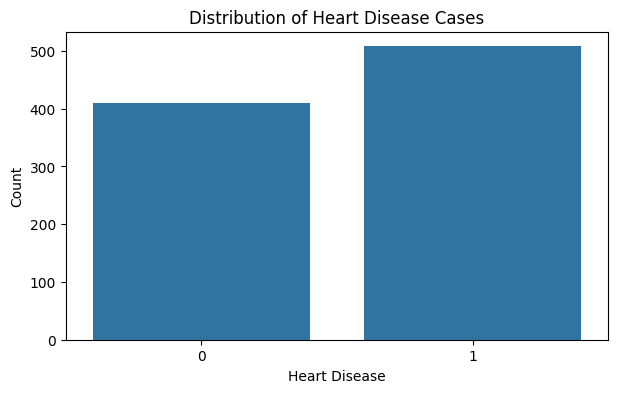

In [8]:
# Exploratory Data Analysis.
#8. Target distribution. Why: This plot shows the number of patients with and without heart disease and helps assess class balance.
plt.figure(figsize=(7, 4))
sns.countplot(data=df_clean, x="HeartDisease", color="C0")
plt.title("Distribution of Heart Disease Cases")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

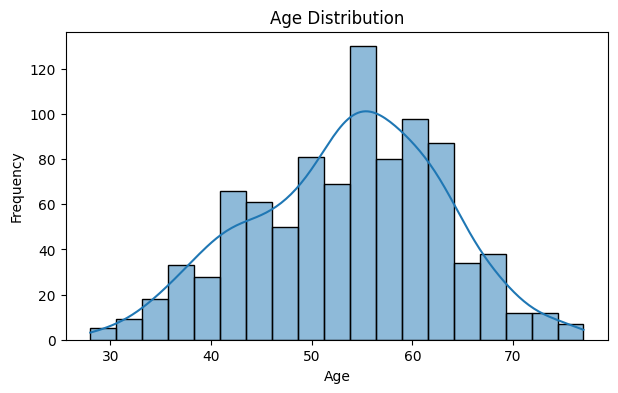

In [9]:
#9. Age distribution. Why: This plot shows the age range of patients. Age can be an important cardiovascular risk factor.
plt.figure(figsize=(7, 4))
sns.histplot(df_clean["Age"], kde=True, color="C0")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

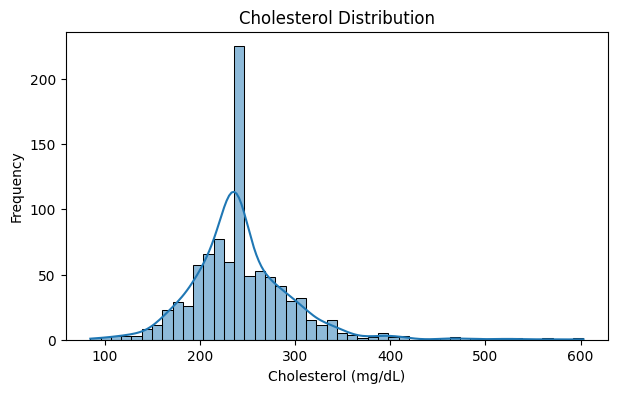

In [10]:
#10. Cholesterol distribution. Why: This plot shows the distribution of serum cholesterol after invalid zero measurements were handled.
plt.figure(figsize=(7, 4))
sns.histplot(df_clean["Cholesterol"], kde=True, color="C0")
plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol (mg/dL)")
plt.ylabel("Frequency")
plt.show()

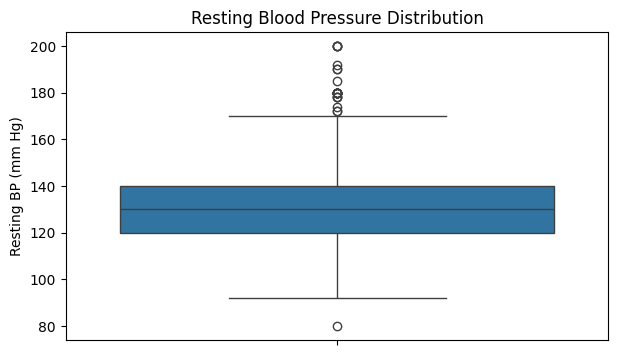

In [11]:
#11. Resting blood pressure distribution. Why: This plot helps identify the range and possible outliers in resting blood pressure.
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_clean, y="RestingBP")
plt.title("Resting Blood Pressure Distribution")
plt.ylabel("Resting BP (mm Hg)")
plt.show()

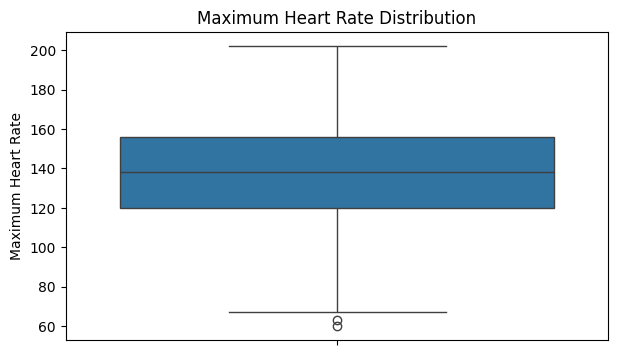

In [12]:
#12. Maximum heart rate distribution. Why: Maximum heart rate achieved during exercise can help distinguish cardiovascular response patterns.
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_clean, y="MaxHR")
plt.title("Maximum Heart Rate Distribution")
plt.ylabel("Maximum Heart Rate")
plt.show()

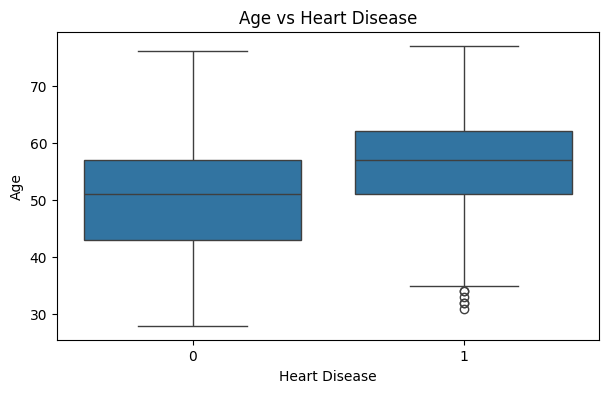

In [13]:
#13. Age vs Heart Disease. Why: This plot compares patient age between the two target classes.
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_clean, x="HeartDisease", y="Age")
plt.title("Age vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Age")
plt.show()

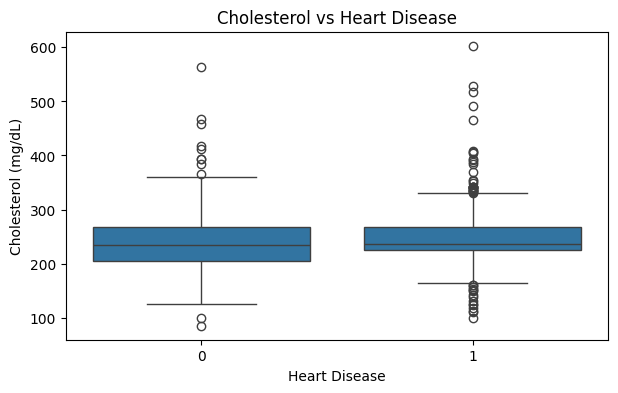

In [14]:
#14. Cholesterol vs Heart Disease. Why: This plot compares cholesterol levels between patients with and without heart disease.
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_clean, x="HeartDisease", y="Cholesterol")
plt.title("Cholesterol vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Cholesterol (mg/dL)")
plt.show()

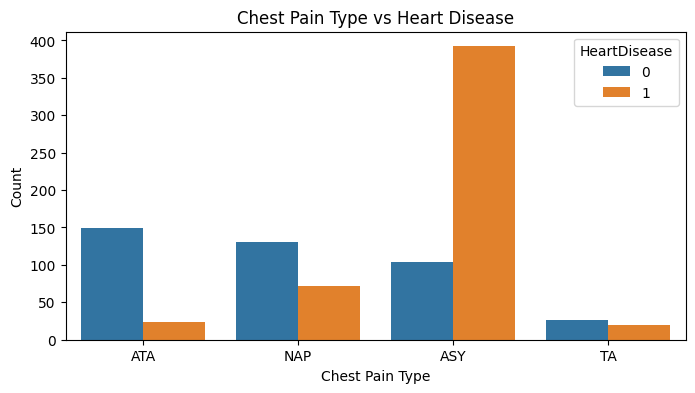

In [15]:
#15. Chest pain type vs Heart Disease. Why: Chest pain type is a clinically important categorical feature that may separate the target classes.
plt.figure(figsize=(8, 4))
sns.countplot(data=df_clean, x="ChestPainType", hue="HeartDisease")
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.show()

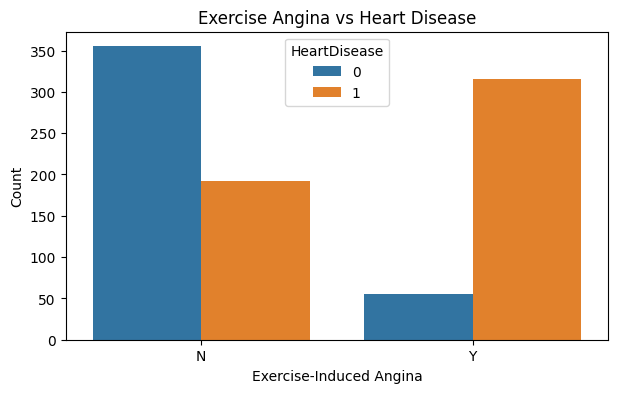

In [16]:
#16. Exercise-induced angina vs Heart Disease. Why: This plot checks whether exercise-induced angina is associated with heart disease status.
plt.figure(figsize=(7, 4))
sns.countplot(data=df_clean, x="ExerciseAngina", hue="HeartDisease")
plt.title("Exercise Angina vs Heart Disease")
plt.xlabel("Exercise-Induced Angina")
plt.ylabel("Count")
plt.show()

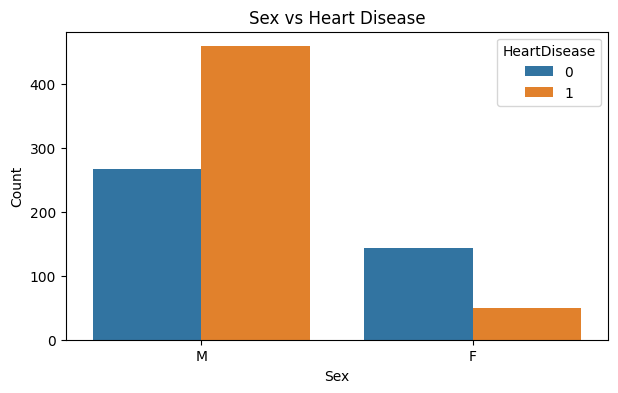

In [17]:
#17. Sex vs Heart Disease. Why: This plot compares the target distribution across male and female patients.
plt.figure(figsize=(7, 4))
sns.countplot(data=df_clean, x="Sex", hue="HeartDisease")
plt.title("Sex vs Heart Disease")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

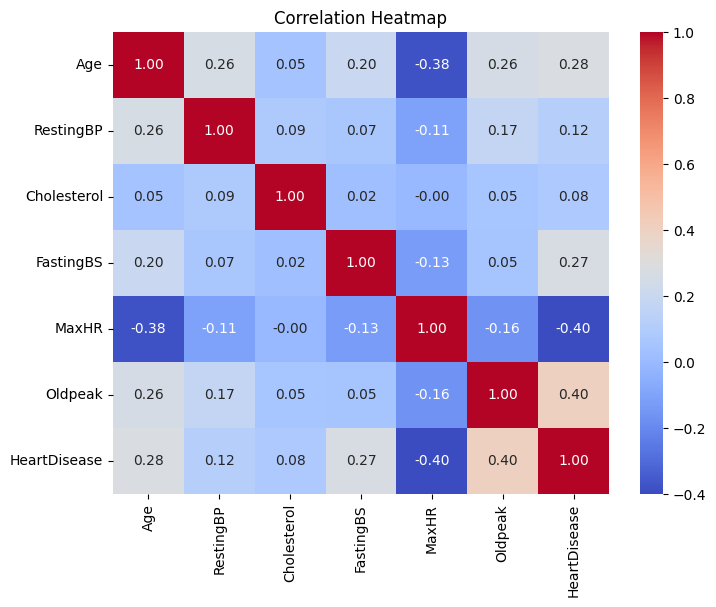

In [18]:
#18. Correlation heatmap. Why: The heatmap summarizes linear relationships among the numerical variables and the target.
numeric_for_corr = [
    "Age", "RestingBP", "Cholesterol", "FastingBS",
    "MaxHR", "Oldpeak", "HeartDisease"
]

plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[numeric_for_corr].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [19]:
#19. Separate features and target. Why: The model learns from X and predicts the binary target y.
X = df_clean.drop(columns=["HeartDisease"])
y = df_clean["HeartDisease"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (918, 16)
Target shape: (918,)


In [20]:
#20. Train-test split. Why: An 80/20 split is used, and stratification preserves the heart-disease class ratio in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (734, 16)
Testing set: (184, 16)


In [21]:
#21. Preprocessing pipeline. Why: Numerical features are scaled and categorical features are one-hot encoded so all models receive appropriate inputs.
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'max_hr_percent']
Categorical features: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'age_group', 'bp_category', 'cholesterol_category', 'exercise_capacity']


In [22]:
#22. Train six algorithms. Why: We compare the same six classification algorithms using multiple metrics rather than accuracy alone.
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    "SVM": SVC(probability=True, class_weight="balanced", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []
for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("feature_selection", SelectKBest(score_func=f_classif, k=10)),
        ("classifier", model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.853261,0.912088,0.813725,0.860104,0.910091
1,Decision Tree,0.750000,0.774510,0.774510,0.774510,0.747011
2,Random Forest,0.777174,0.785047,0.823529,0.803828,0.867109
3,SVM,0.815217,0.840000,0.823529,0.831683,0.880918
4,KNN,0.788043,0.805825,0.813725,0.809756,0.868962
5,Gradient Boosting,0.809783,0.825243,0.833333,0.829268,0.883967


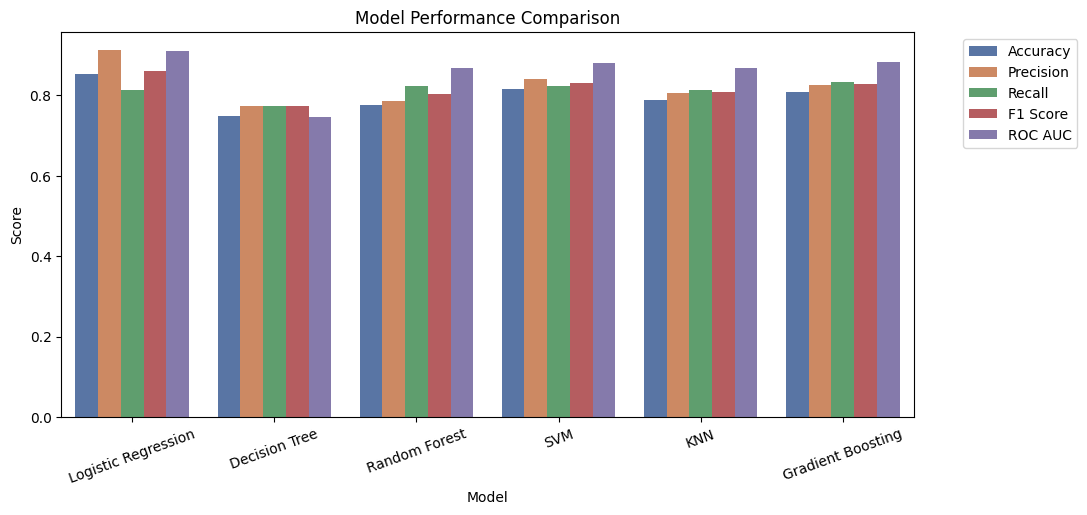

In [23]:
#23. Model performance comparison plot. Why: This chart makes it easy to compare the six algorithms across accuracy, precision, recall, F1-score, and ROC AUC.
results_melted = results_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 5))
sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric", palette="deep")
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [24]:
#24. Hyperparameter tuning. Why: GridSearchCV tests Random Forest settings and feature-selection sizes using five-fold cross-validation and F1-score.
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("classifier", RandomForestClassifier(random_state=42, class_weight="balanced"))
])

param_grid = {
    "feature_selection__k": [8, 10, 12, "all"],
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)
print("Best cross-validation F1 score:")
print(grid_search.best_score_)

Best parameters:
{'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200, 'feature_selection__k': 'all'}
Best cross-validation F1 score:
0.8722426226420043


In [25]:
#25. Evaluate final model. Why: Accuracy, precision, recall, F1-score, ROC AUC, and the classification report are used to evaluate the tuned model.
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.8967391304347826
Precision: 0.8878504672897196
Recall: 0.9313725490196079
F1 Score: 0.9090909090909091
ROC AUC: 0.9270086083213773

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.85      0.88        82
           1       0.89      0.93      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.89      0.89       184
weighted avg       0.90      0.90      0.90       184



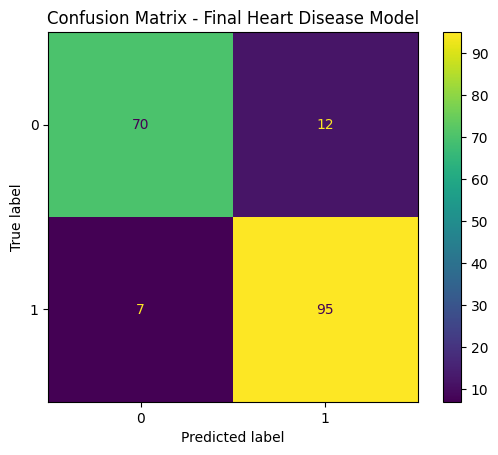

In [26]:
#26. Confusion matrix. Why: The confusion matrix shows correct and incorrect predictions for patients with and without heart disease.
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Final Heart Disease Model")
plt.show()

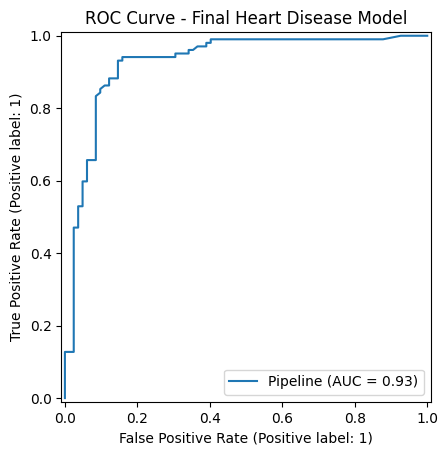

In [27]:
#27. ROC curve. Why: The ROC curve shows how well the final model separates the two classes across different decision thresholds.
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC Curve - Final Heart Disease Model")
plt.show()

In [28]:
#28. Save files. Why: We save the tuned model, features, target, and model-comparison results for deployment and submission.
joblib.dump(best_model, "best_heart_disease_model.pkl")

X.to_csv("X_features.csv", index=False)
y.to_csv("y_target.csv", index=False)
results_df.to_csv("model_comparison_results.csv", index=False)

print("Files saved successfully.")

Files saved successfully.
